# Perceptron model for Binary Classification

The goal is to implement and understand the Perceptron model for binary classification.


## Part (a): Implementation of the Perceptron Model

In [1]:
import itertools
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron as SklearnPerceptron
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split

class CustomPerceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000, random_state=None):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.accuracy_history = []  # Track accuracy over epochs

    def normalize(self, X):
        return (X - np.mean(X, axis=0)) / np.std(X, axis=0)

    def fit(self, X, y):
        X = self.normalize(X)
        n_samples, n_features = X.shape

        if self.random_state is not None:
            np.random.seed(self.random_state)

        # Initialize weights and bias
        self.weights = np.zeros(n_features)  # Changed to zero initialization
        self.bias = 0

        for epoch in range(self.n_iters):
            correct_predictions = 0
            for idx in range(n_samples):
                x_i = X[idx]
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self._activation(linear_output)
                update = self.learning_rate * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update

                # Accuracy tracking
                if y_predicted == y[idx]:
                    correct_predictions += 1

            # Track accuracy at each epoch
            self.accuracy_history.append(correct_predictions / n_samples)

    def predict(self, X):
        X = self.normalize(X)  # Normalize in predict as well
        linear_output = np.dot(X, self.weights) + self.bias
        return self._activation(linear_output)

    def _activation(self, x):
        return np.where(x >= 0, 1, 0)

    def plot_combined_graph(self, X, y, feature_combination):
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        # Plot decision boundary
        ax[0].set_title(f"Decision Boundary: {feature_combination}")
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(
            np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01)
        )
        Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        ax[0].contourf(xx, yy, Z, alpha=0.8)
        ax[0].scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", marker="o")
        ax[0].set_xlabel(feature_combination[0])
        ax[0].set_ylabel(feature_combination[1])

        # Plot accuracy over epochs
        ax[1].set_title("Accuracy Over Epochs")
        ax[1].plot(
            range(1, len(self.accuracy_history) + 1), self.accuracy_history, marker="o"
        )
        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Accuracy")
        ax[1].grid()

        plt.tight_layout()
        plt.show()

## Part (b): Evaluation and Visualization of the Perceptron Model

Learning Rate: 0.0001, Epochs: 100


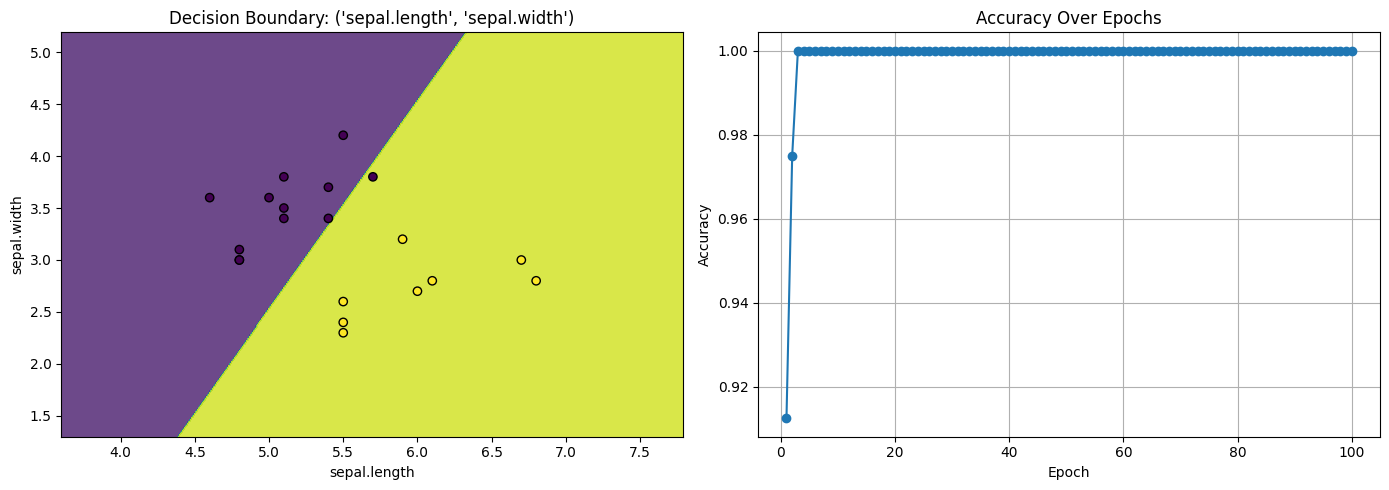

Learning Rate: 0.001, Epochs: 100


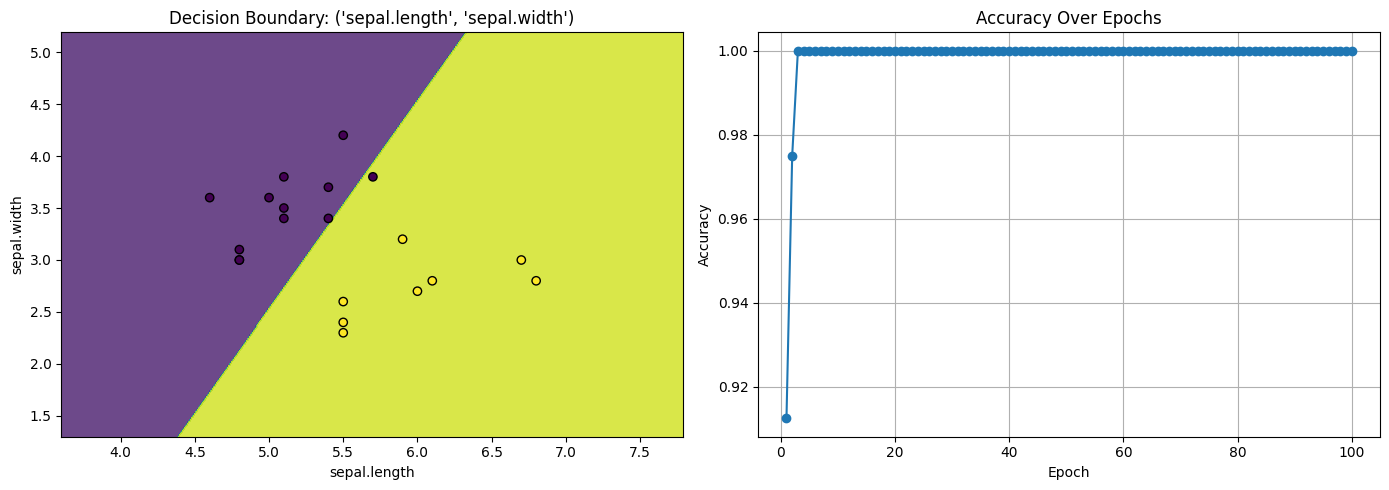

Learning Rate: 0.0001, Epochs: 100


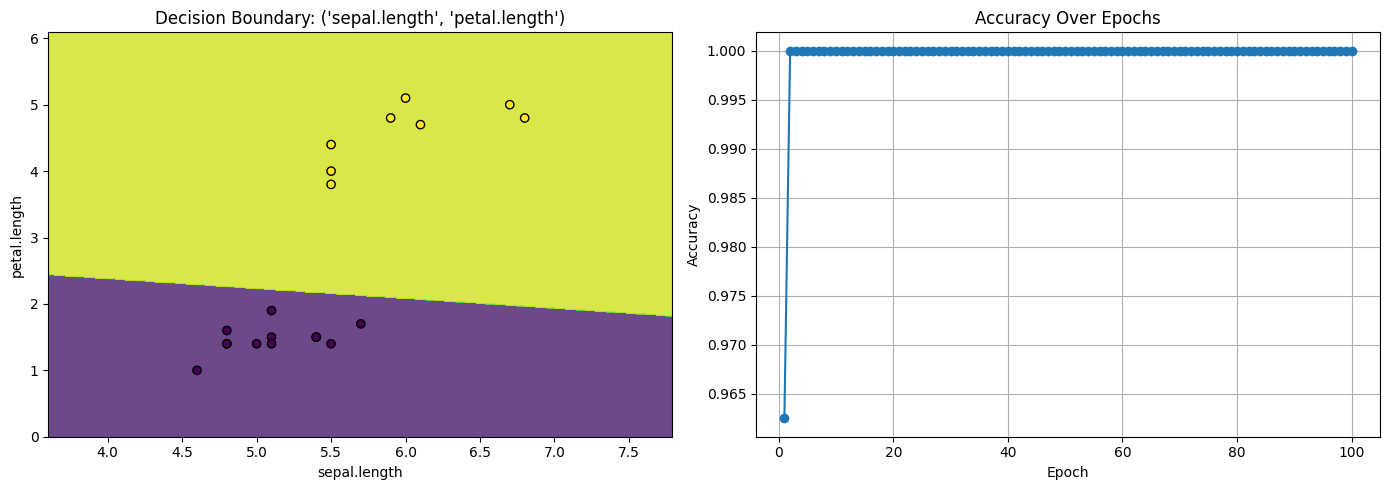

Learning Rate: 0.001, Epochs: 100


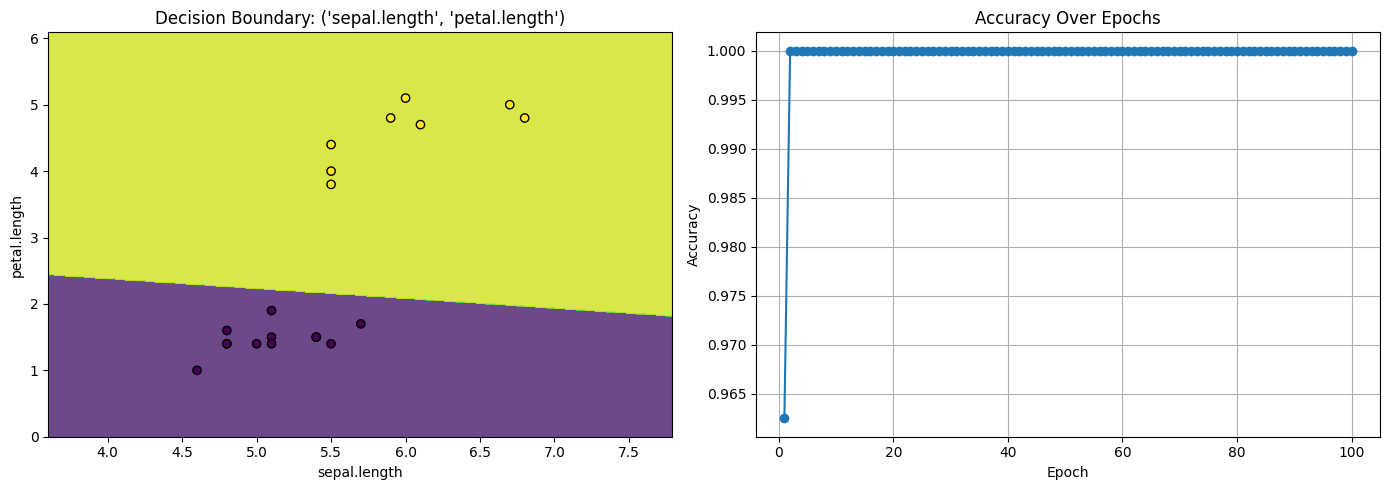

Learning Rate: 0.0001, Epochs: 100


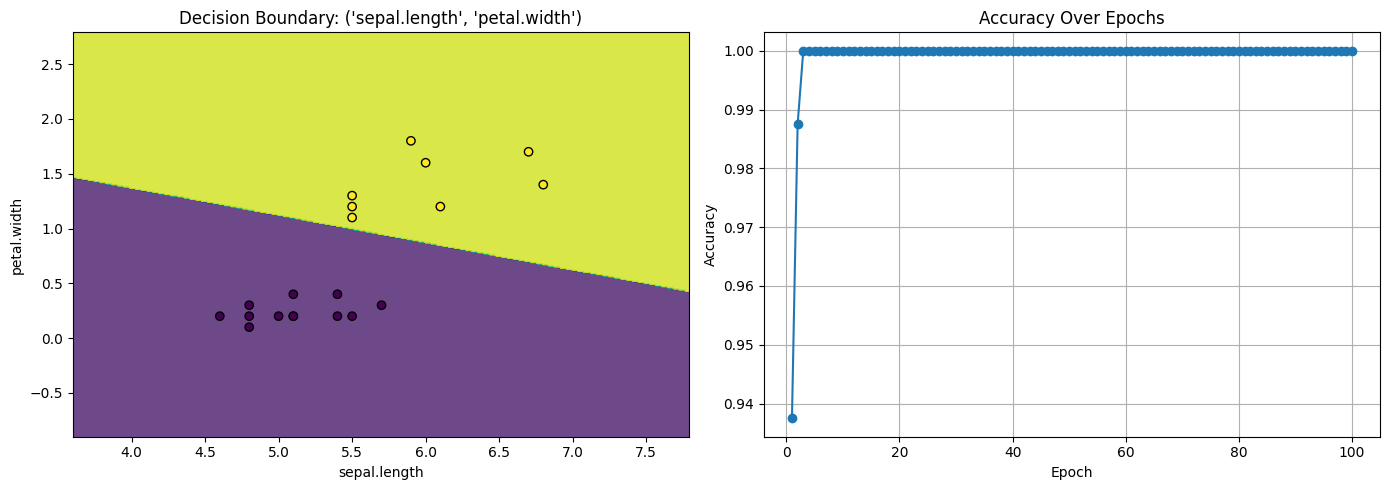

Learning Rate: 0.001, Epochs: 100


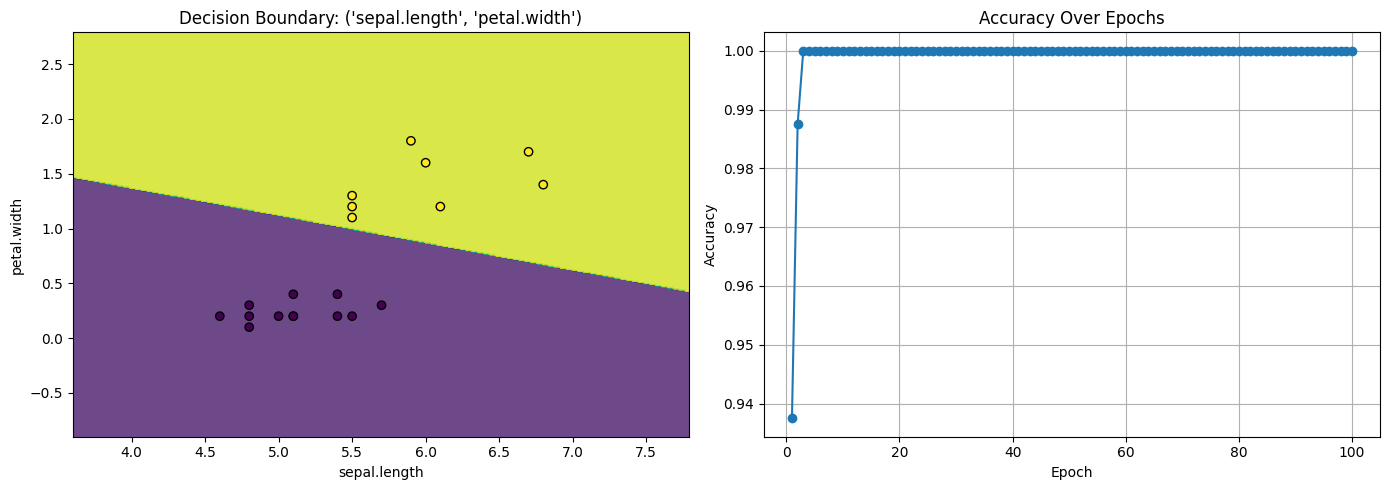

Learning Rate: 0.0001, Epochs: 100


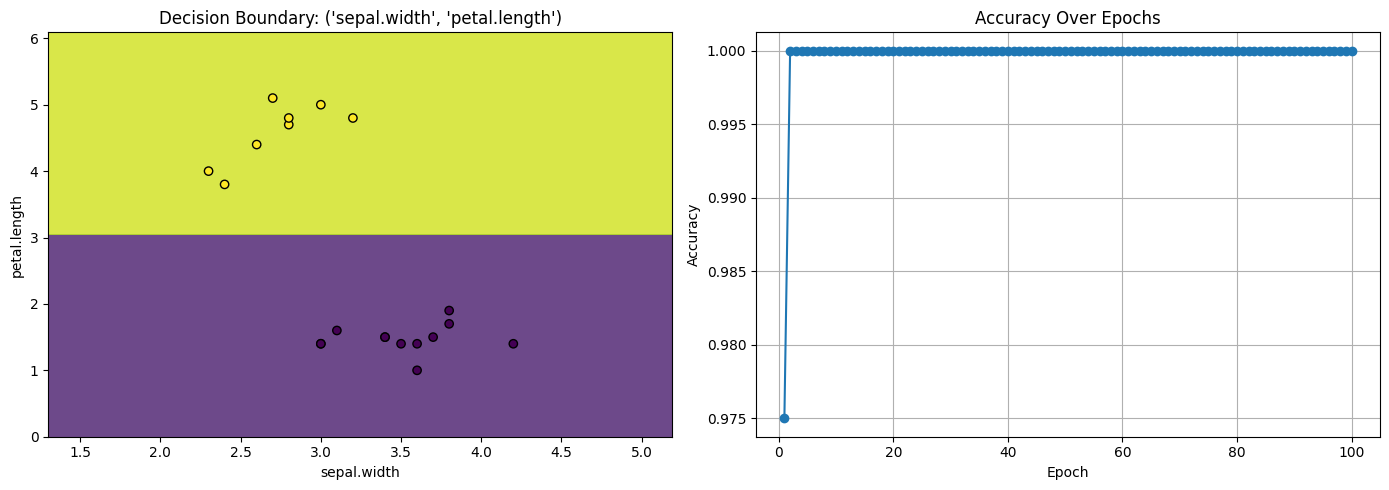

Learning Rate: 0.001, Epochs: 100


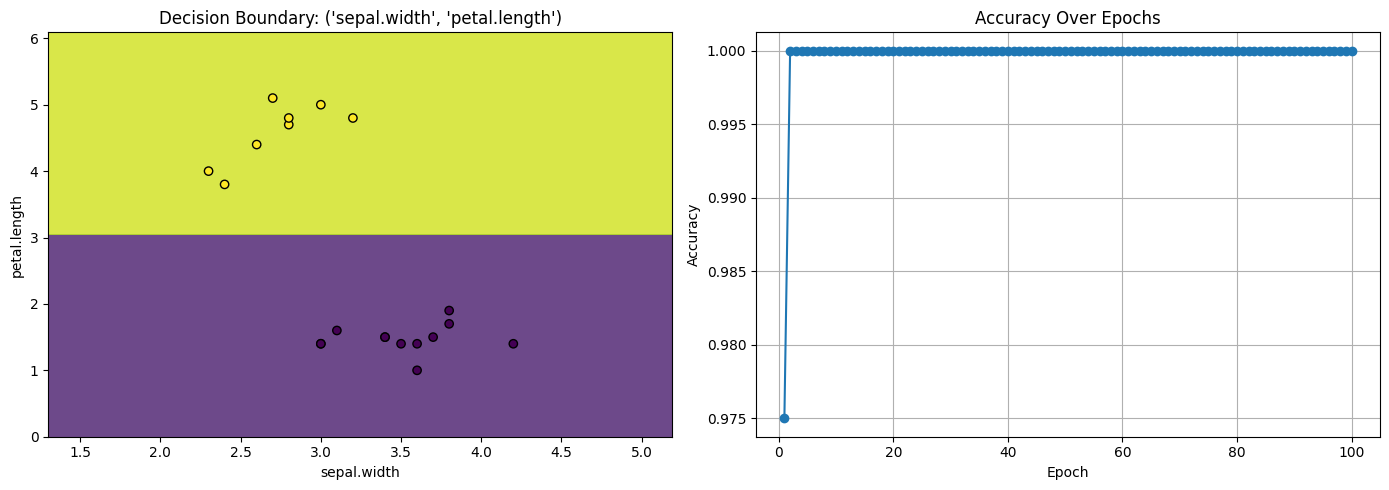

Learning Rate: 0.0001, Epochs: 100


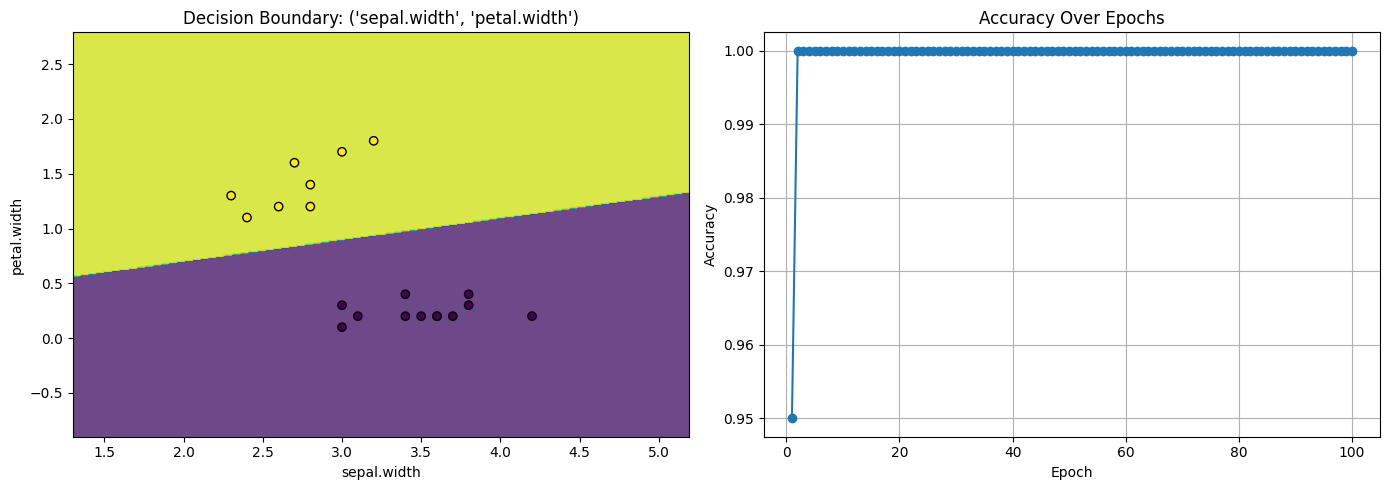

Learning Rate: 0.001, Epochs: 100


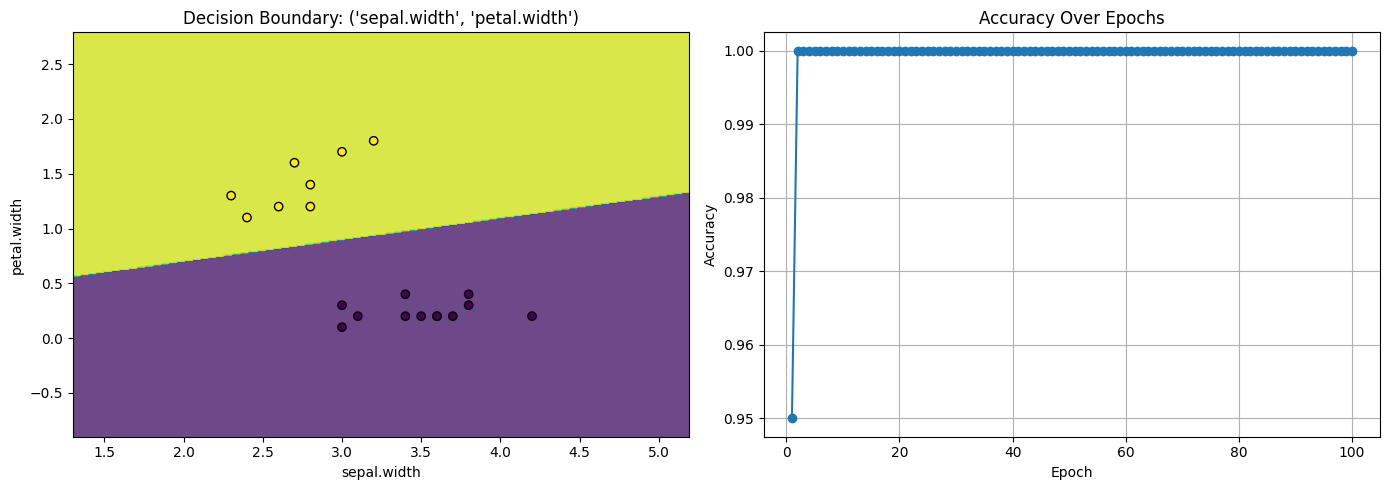

Learning Rate: 0.0001, Epochs: 100


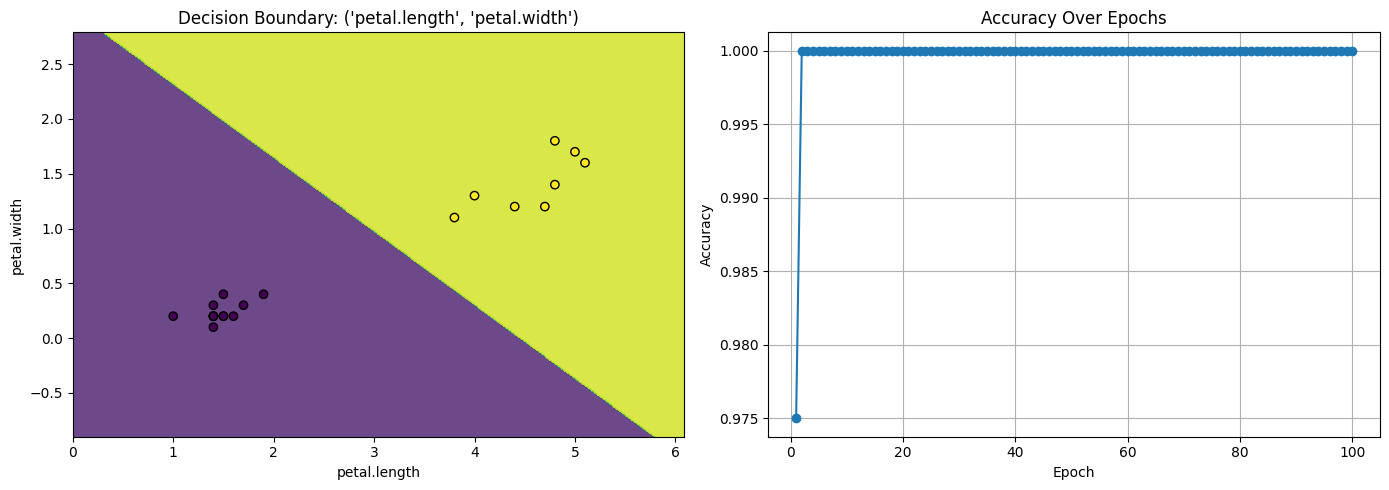

Learning Rate: 0.001, Epochs: 100


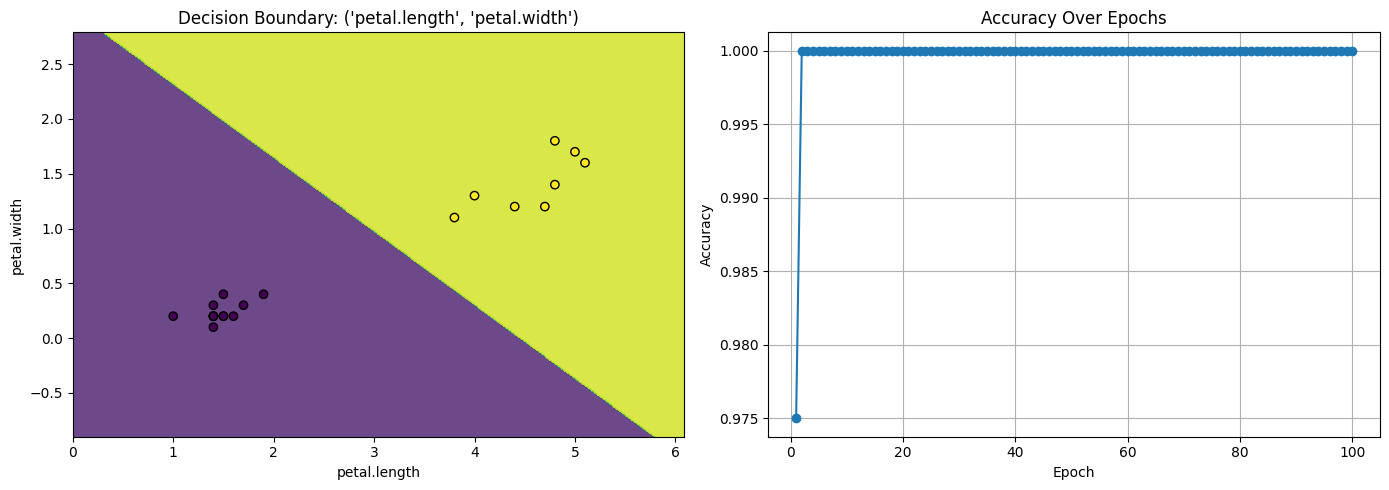

Learning Rate: 0.0001, Epochs: 100


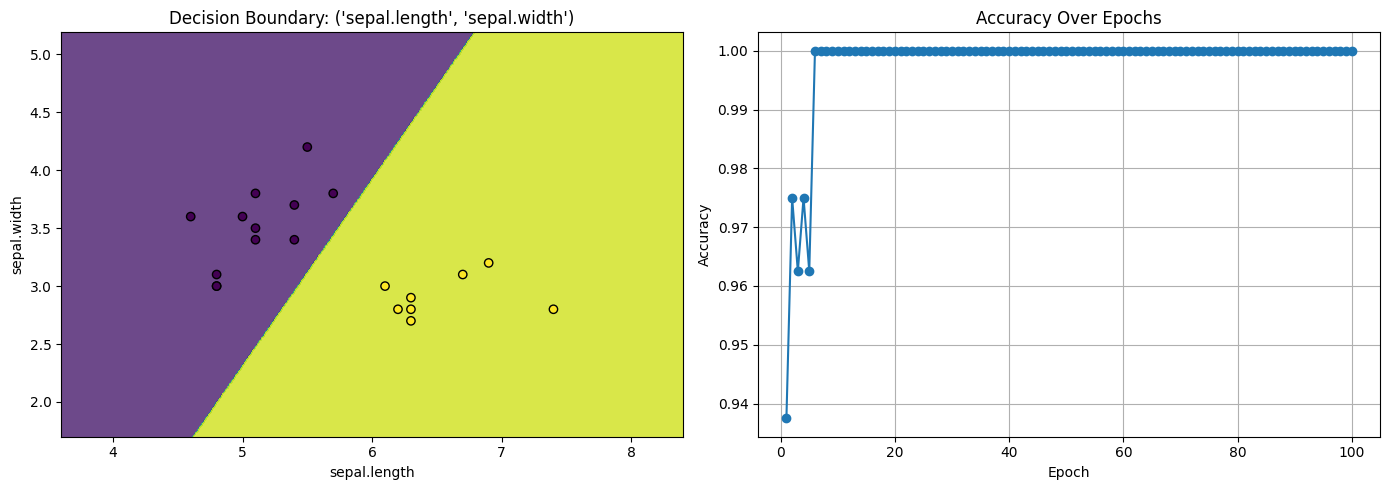

Learning Rate: 0.001, Epochs: 100


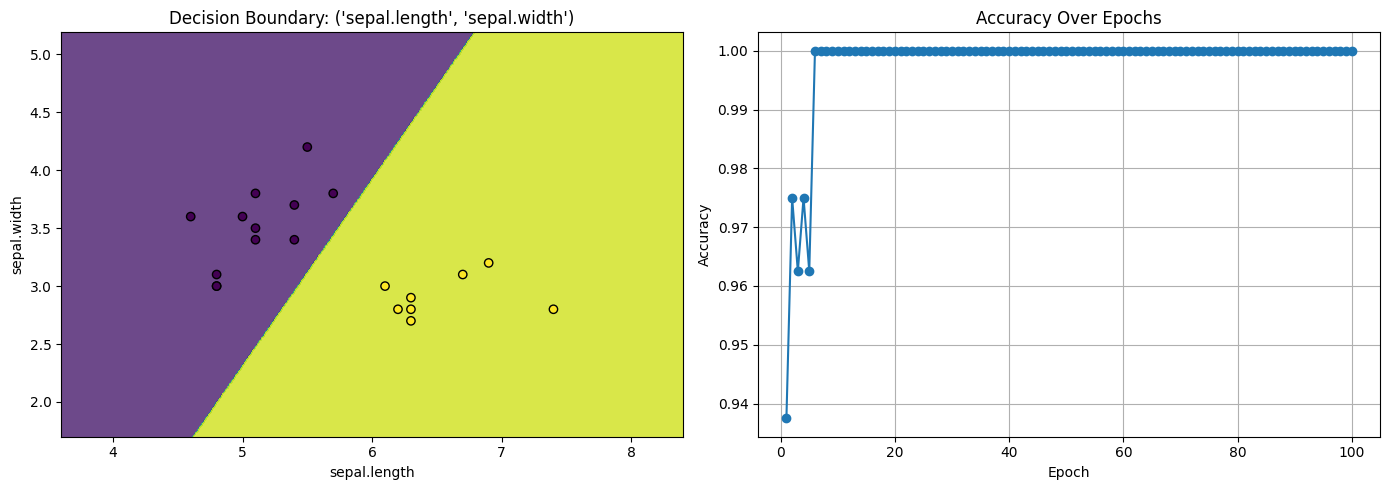

Learning Rate: 0.0001, Epochs: 100


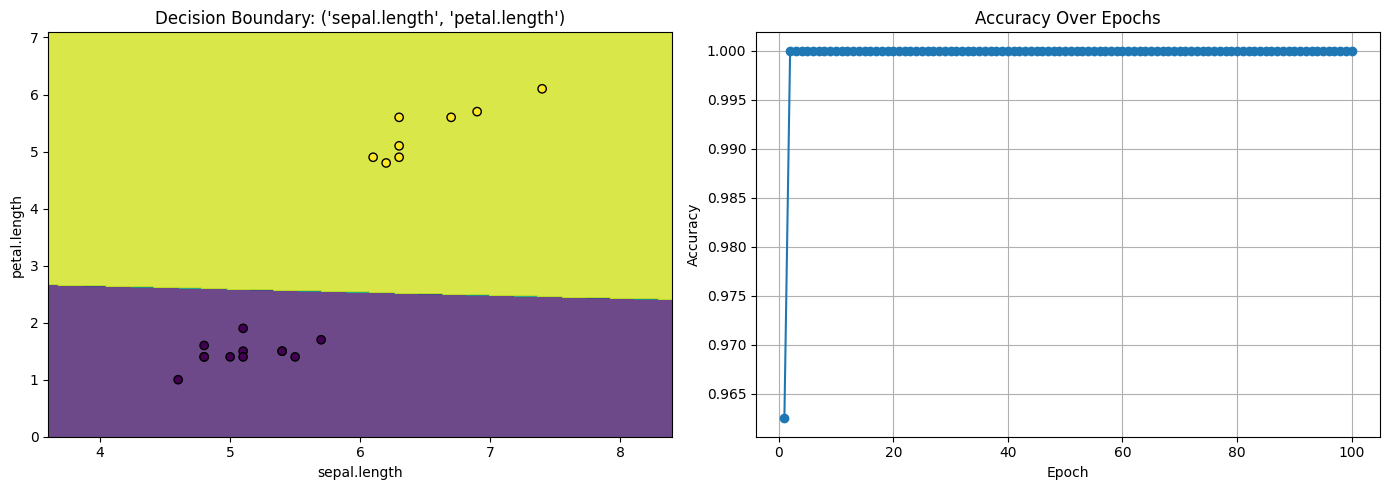

Learning Rate: 0.001, Epochs: 100


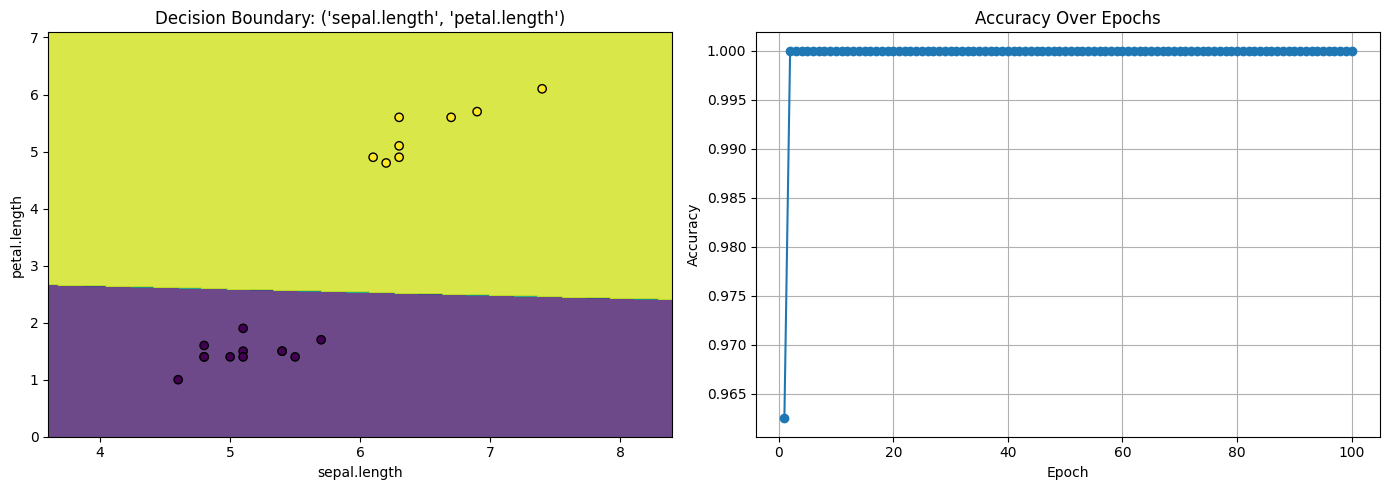

Learning Rate: 0.0001, Epochs: 100


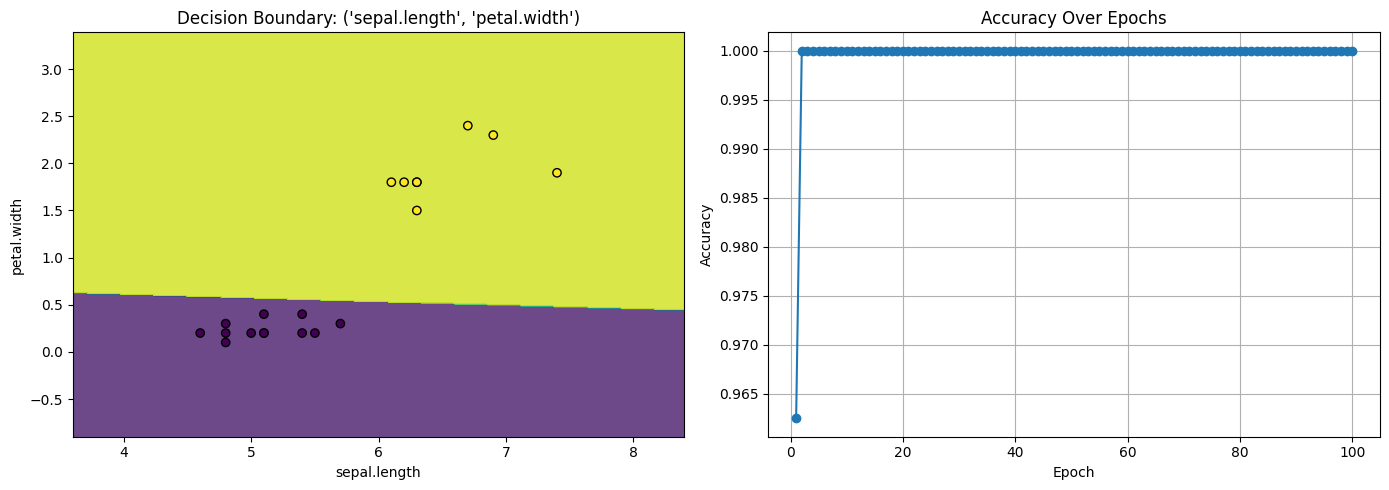

Learning Rate: 0.001, Epochs: 100


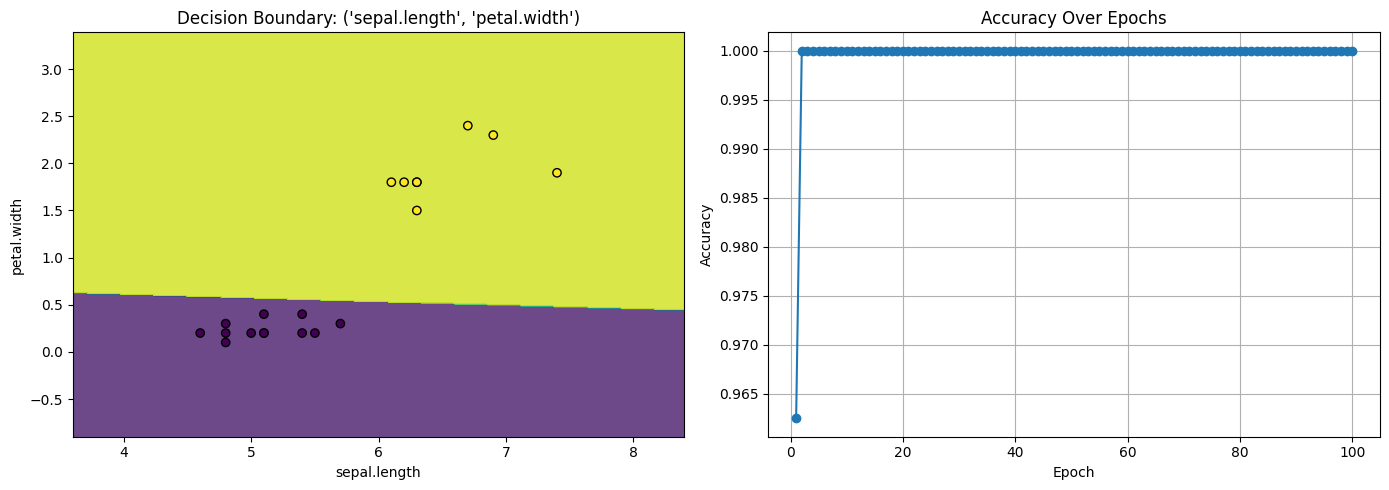

Learning Rate: 0.0001, Epochs: 100


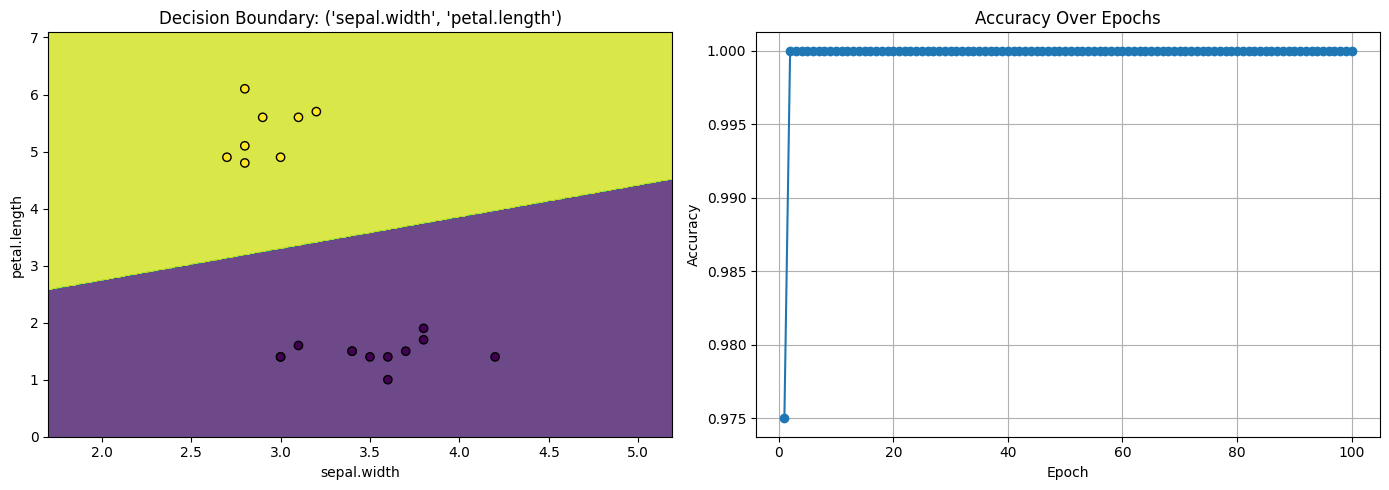

Learning Rate: 0.001, Epochs: 100


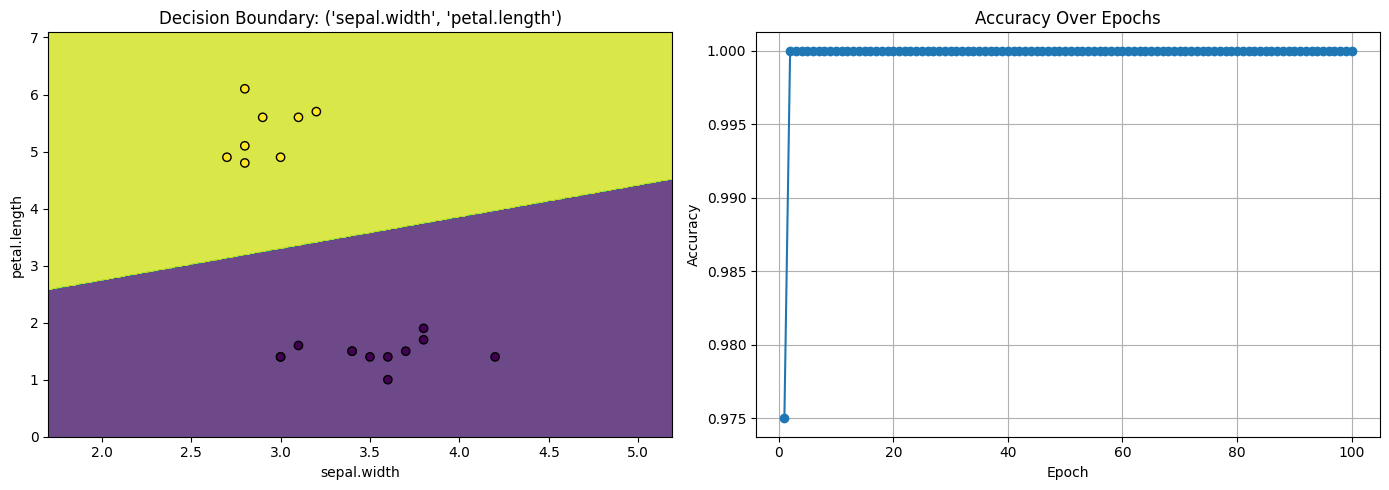

Learning Rate: 0.0001, Epochs: 100


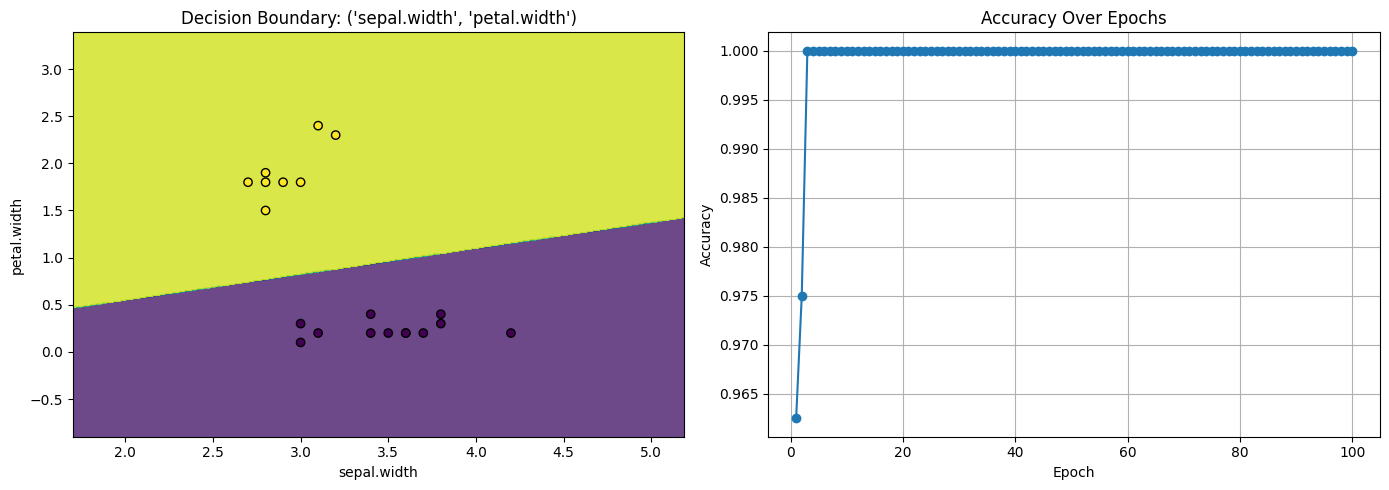

Learning Rate: 0.001, Epochs: 100


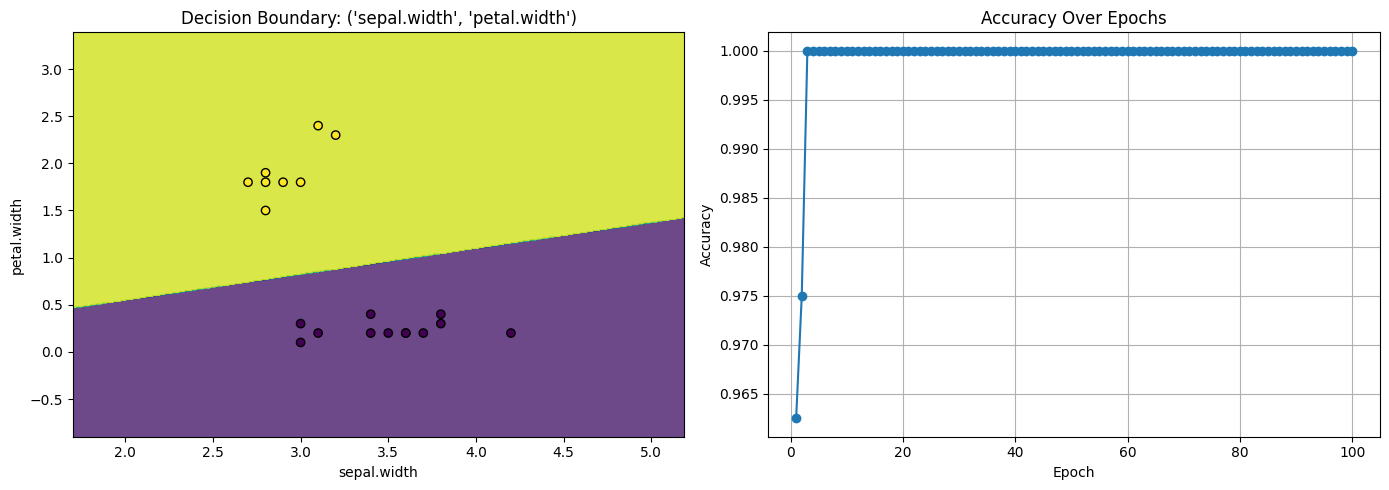

Learning Rate: 0.0001, Epochs: 100


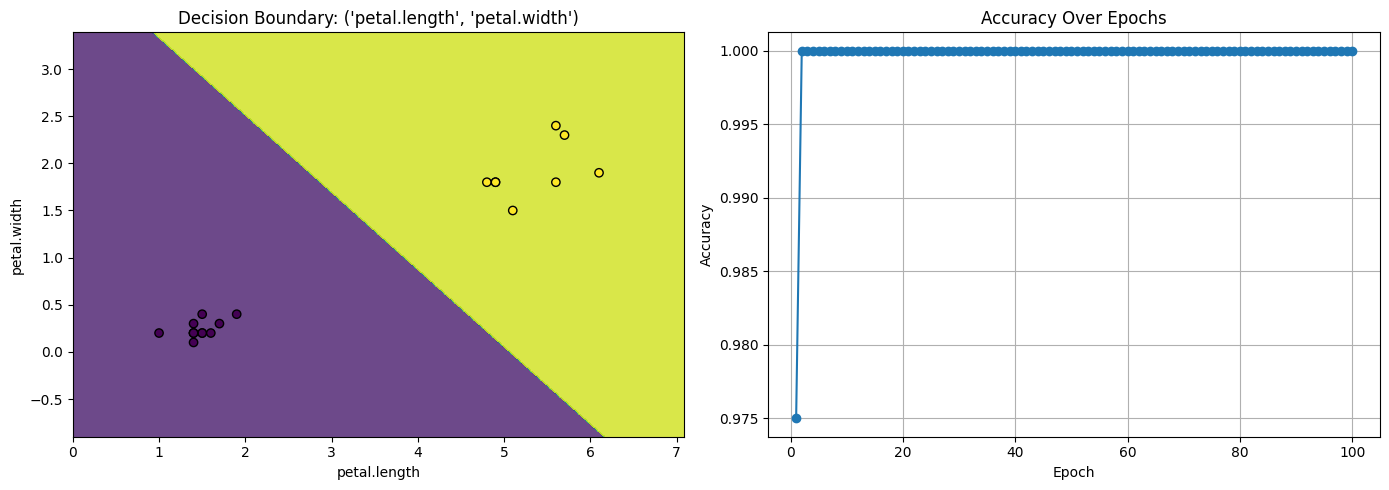

Learning Rate: 0.001, Epochs: 100


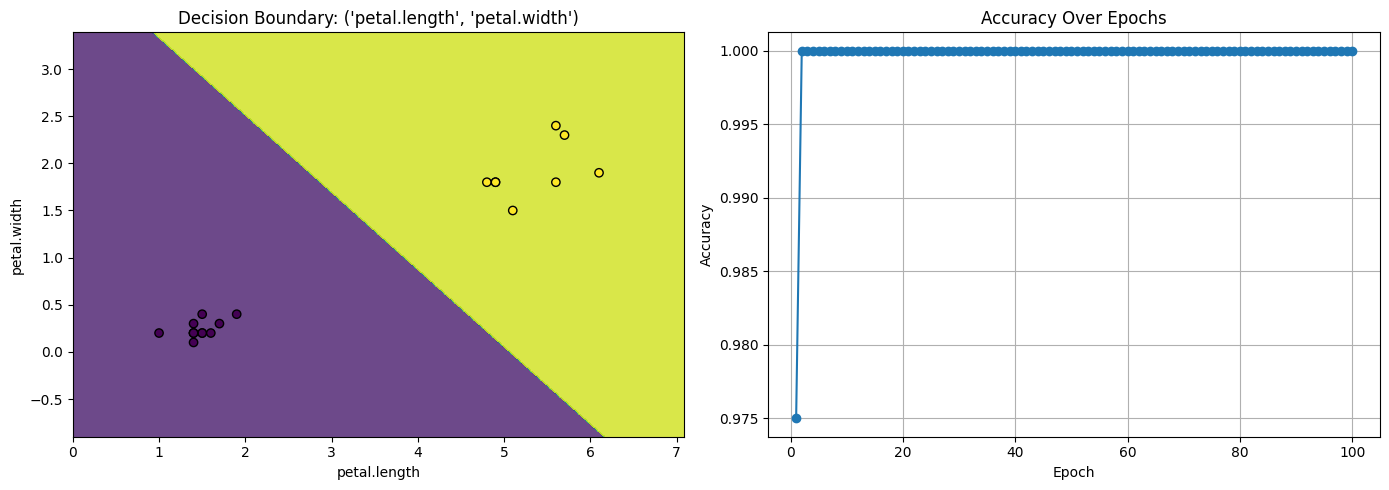

Learning Rate: 0.0001, Epochs: 100


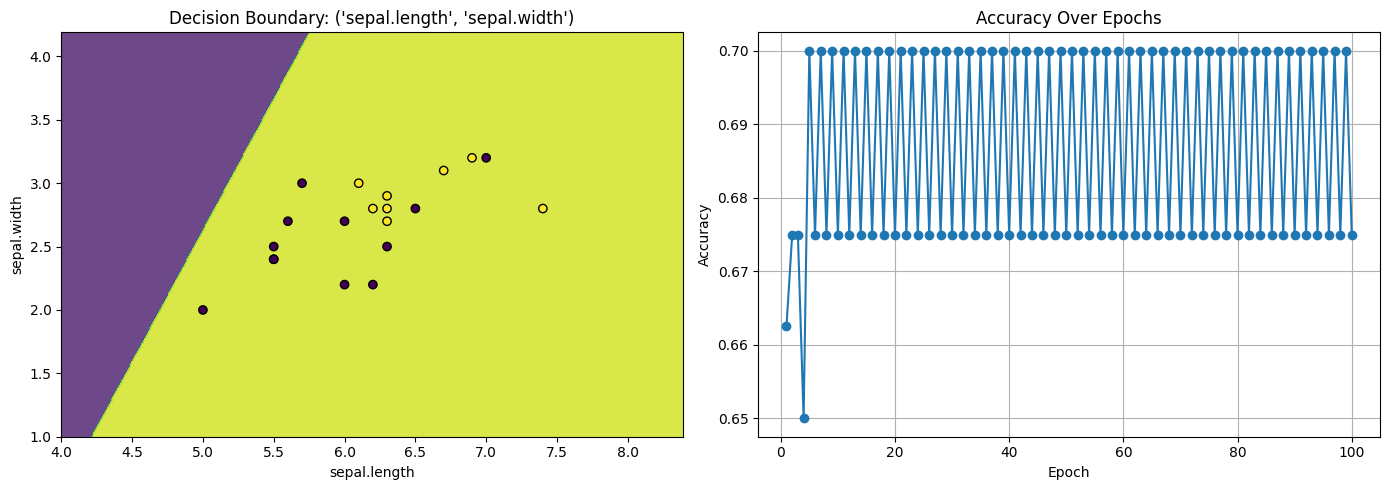

Learning Rate: 0.001, Epochs: 100


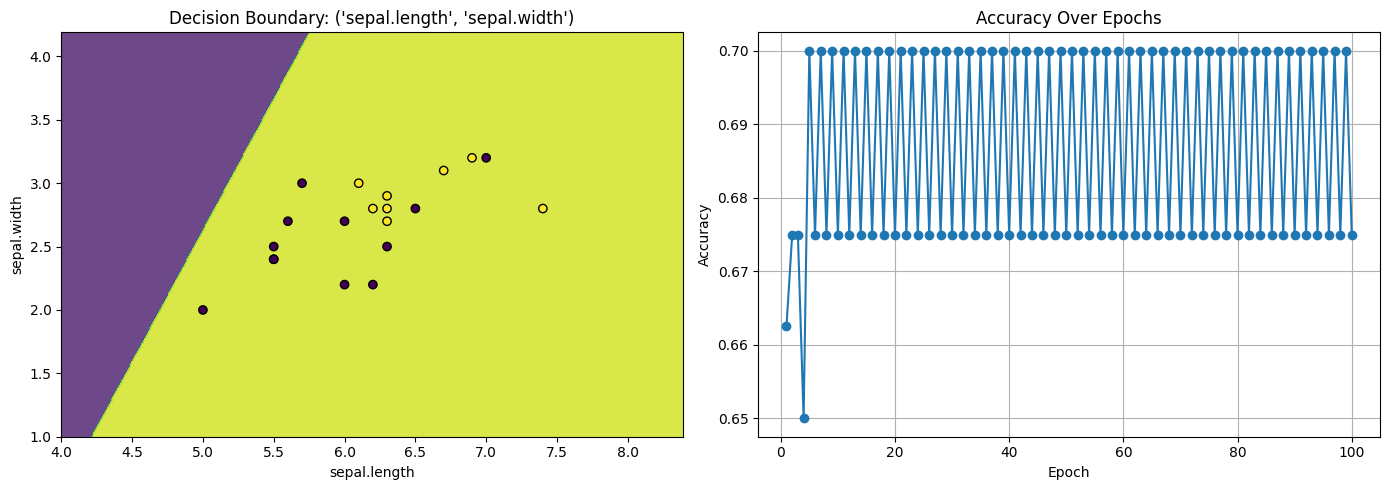

Learning Rate: 0.0001, Epochs: 100


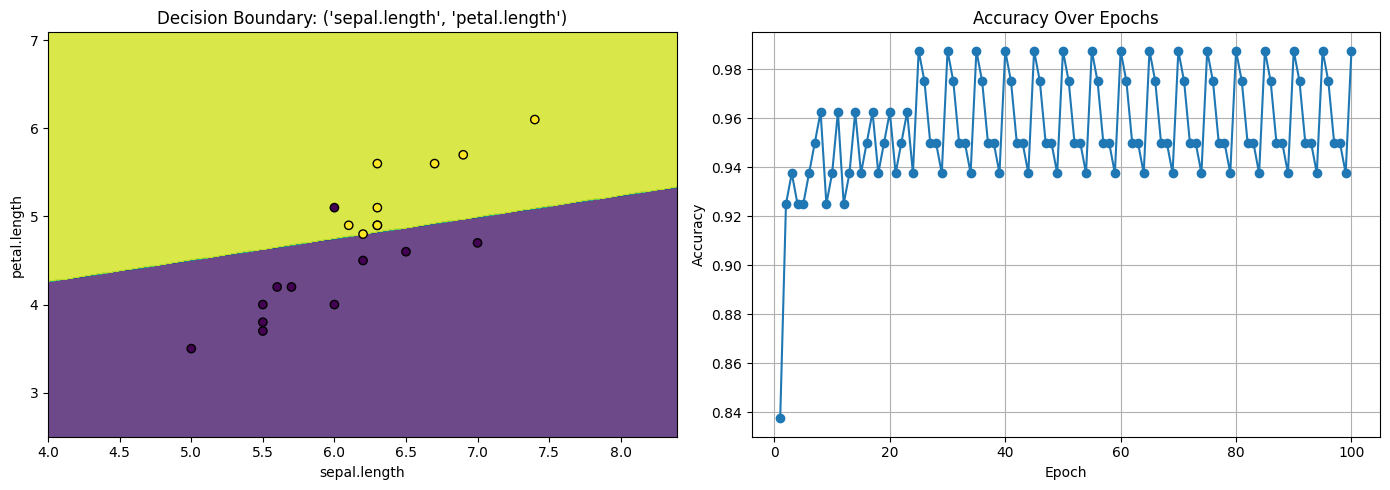

Learning Rate: 0.001, Epochs: 100


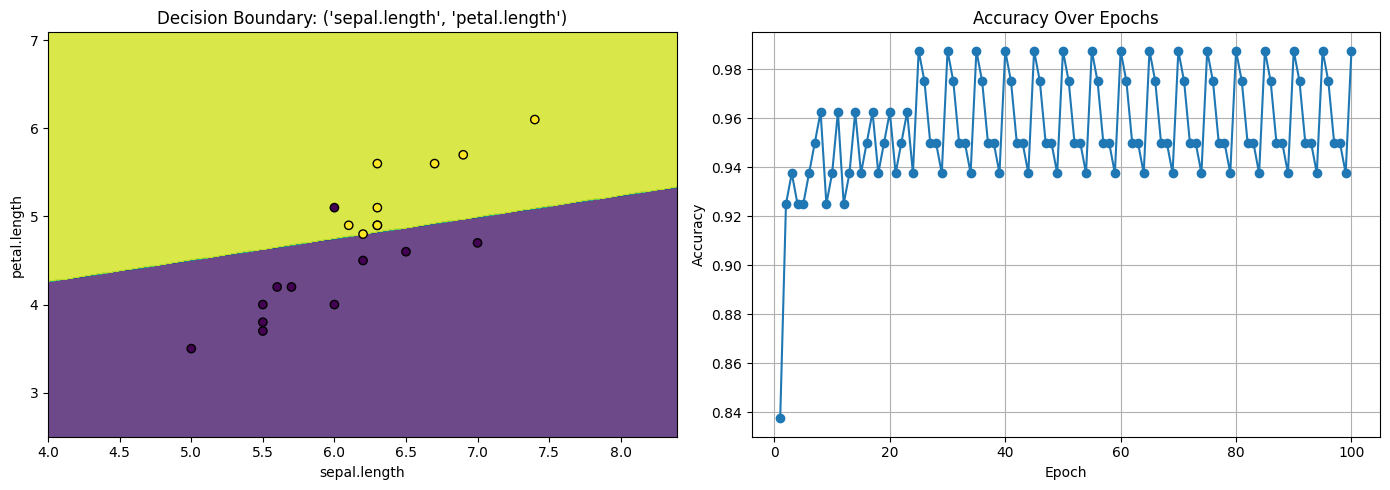

Learning Rate: 0.0001, Epochs: 100


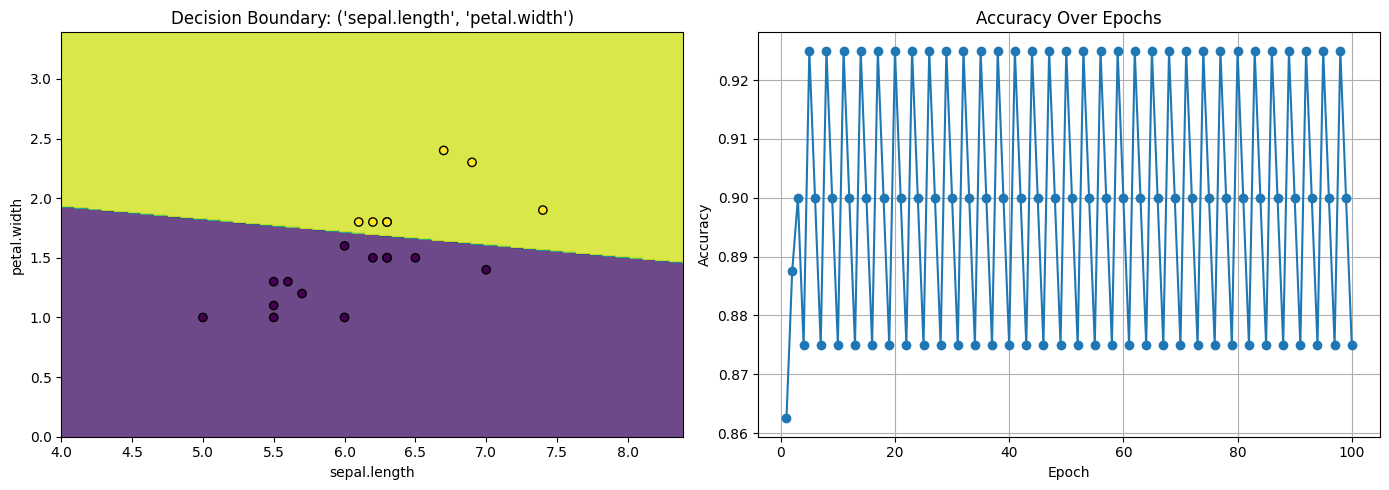

Learning Rate: 0.001, Epochs: 100


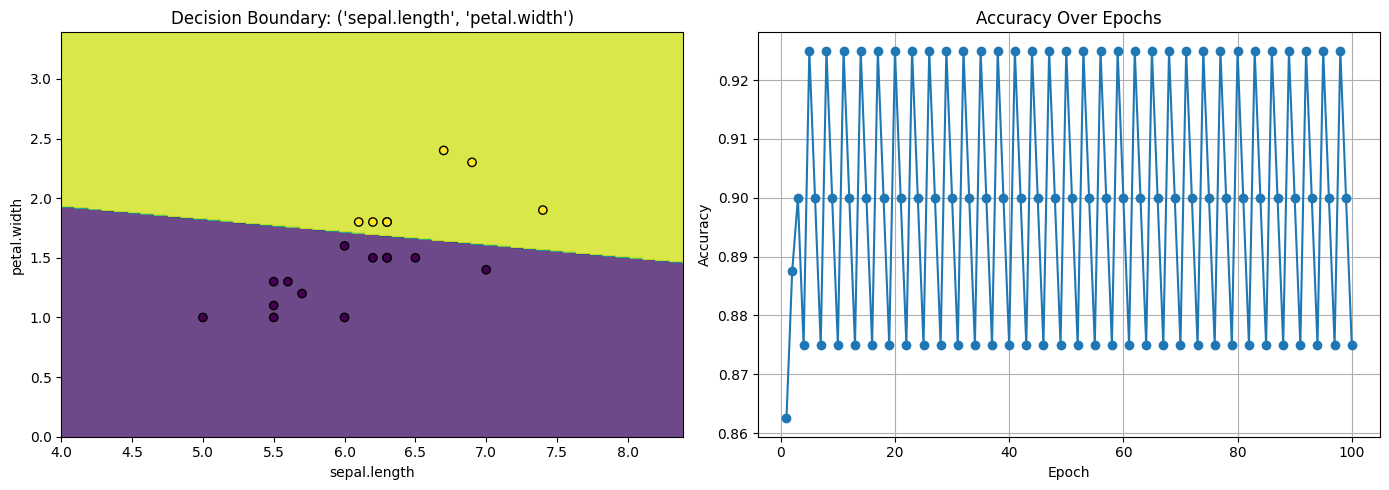

Learning Rate: 0.0001, Epochs: 100


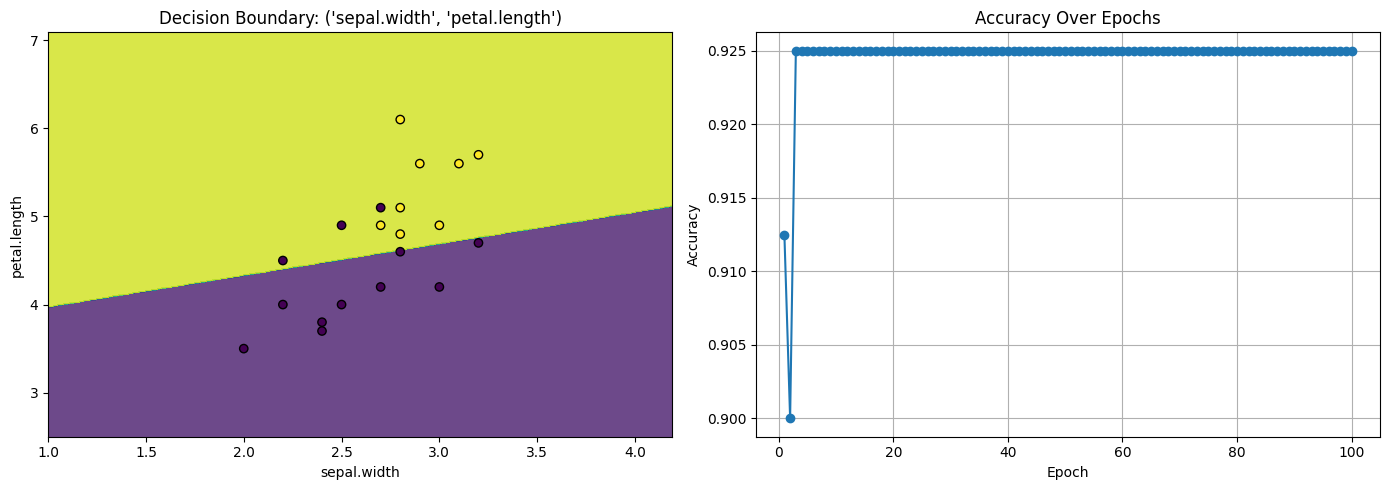

Learning Rate: 0.001, Epochs: 100


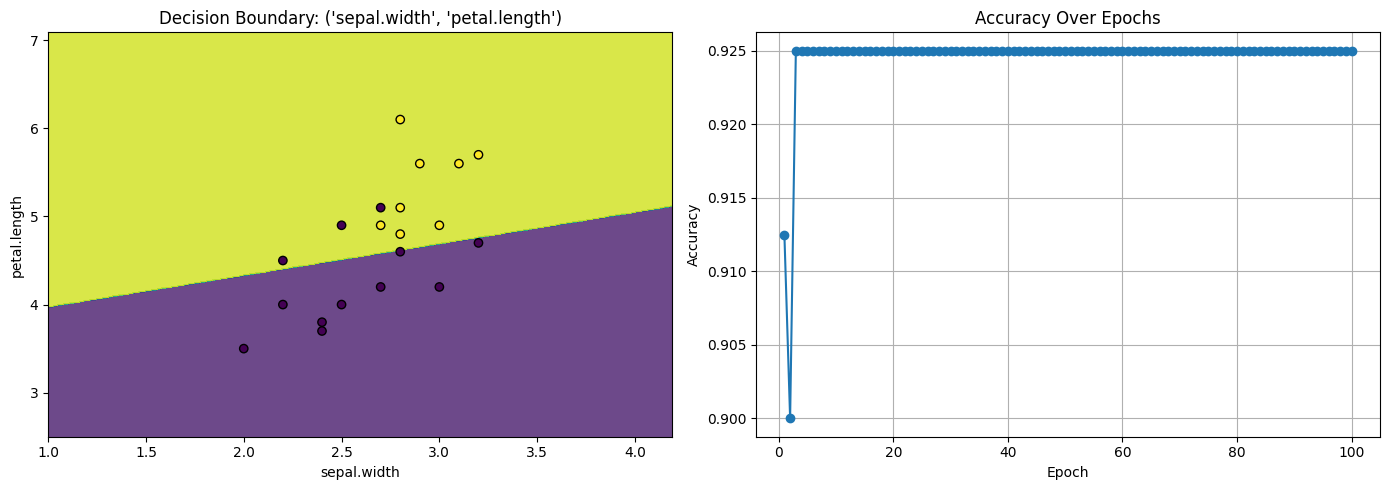

Learning Rate: 0.0001, Epochs: 100


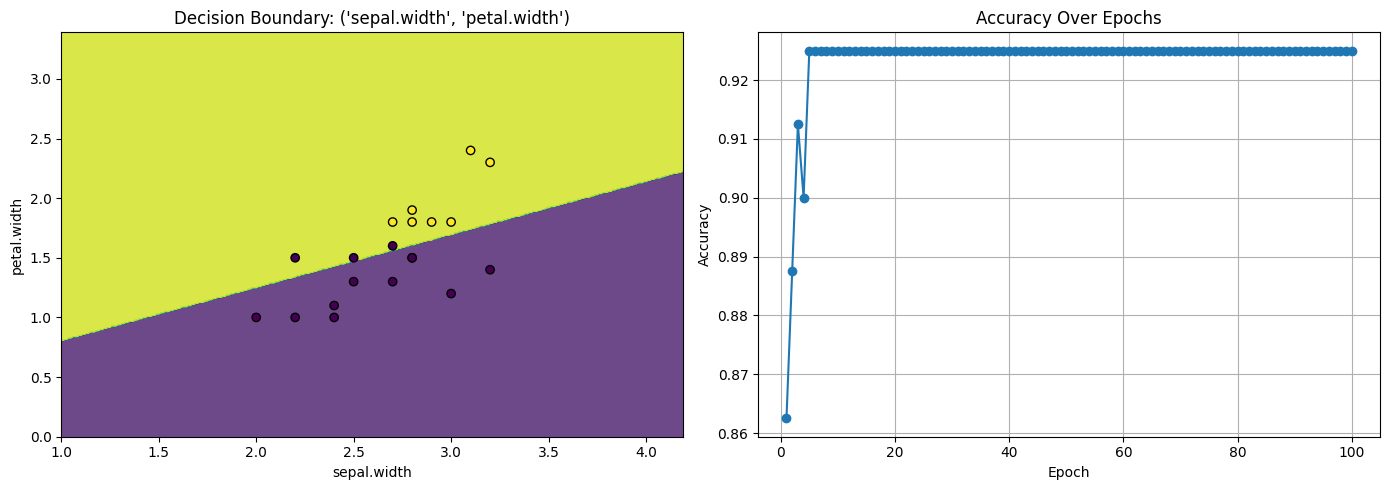

Learning Rate: 0.001, Epochs: 100


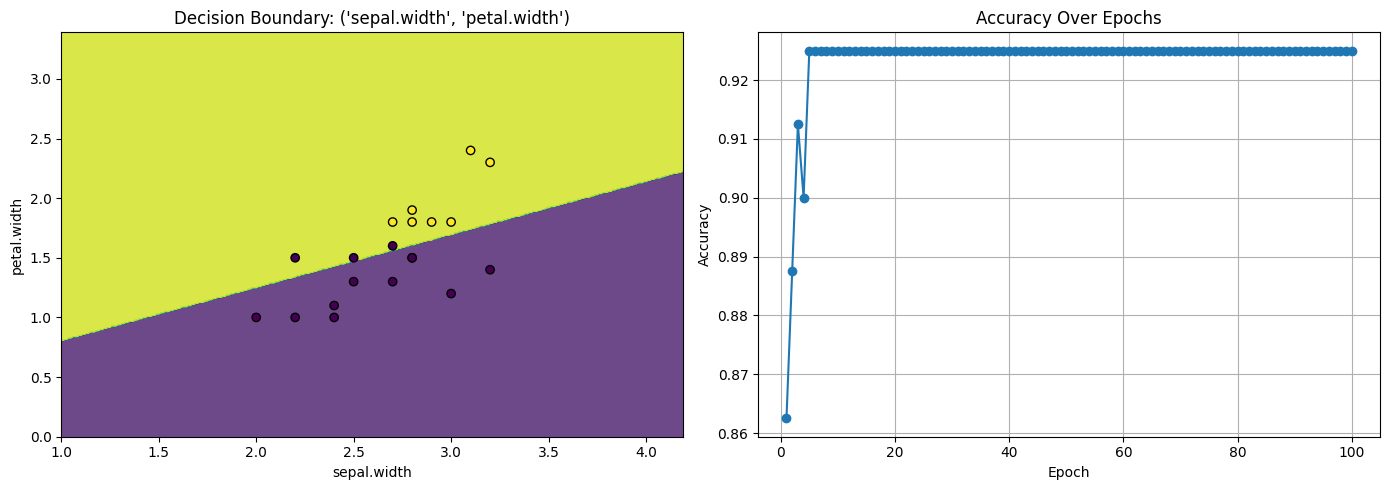

Learning Rate: 0.0001, Epochs: 100


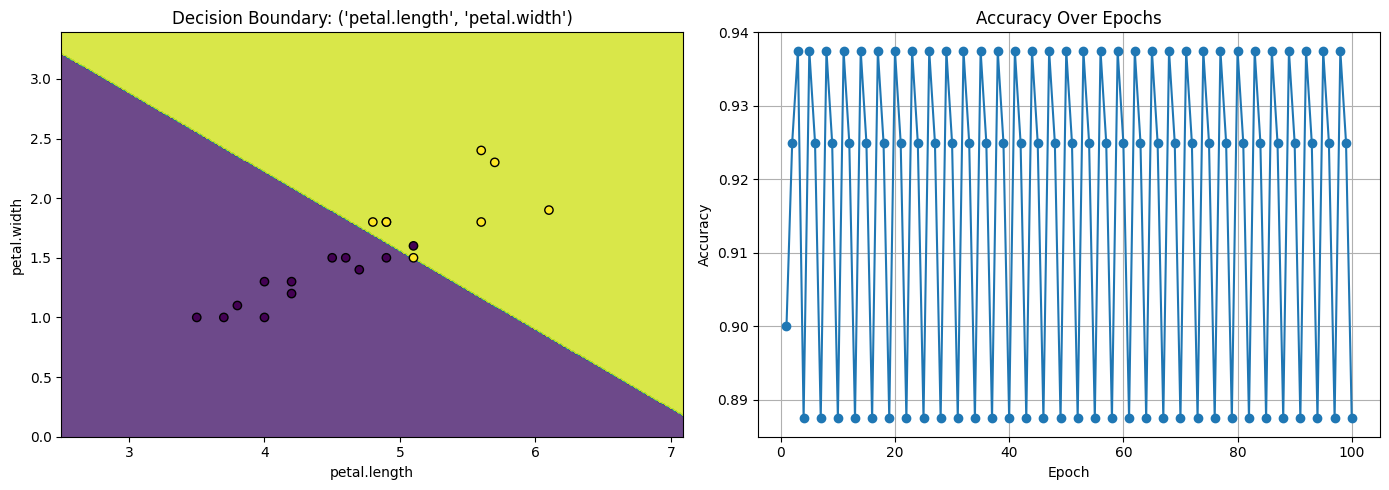

Learning Rate: 0.001, Epochs: 100


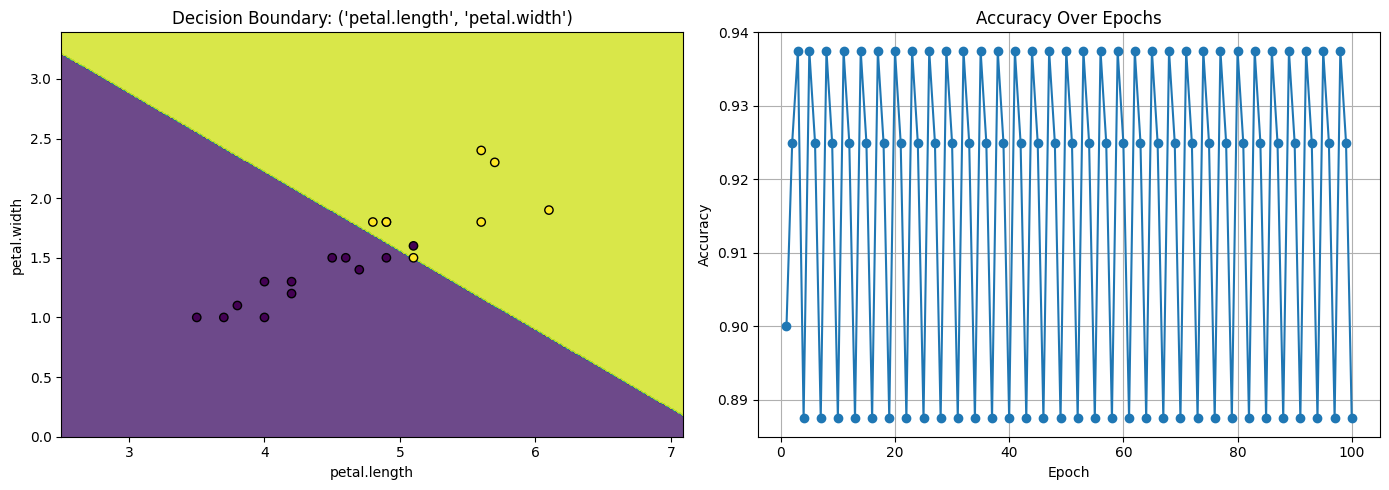

+----+-----------------------------+----------------------------------+-----------------+----------+-------------------+--------------------+
|    | Class Combination           | Feature Combination              |   Learning Rate |   Epochs |   accuracy_custom |   accuracy_sklearn |
+====+=============================+==================================+=================+==========+===================+====================+
|  0 | ('Setosa', 'Versicolor')    | ('sepal.length', 'sepal.width')  |          0.0001 |      100 |              0.95 |               1    |
+----+-----------------------------+----------------------------------+-----------------+----------+-------------------+--------------------+
|  1 | ('Setosa', 'Versicolor')    | ('sepal.length', 'sepal.width')  |          0.001  |      100 |              0.95 |               0.95 |
+----+-----------------------------+----------------------------------+-----------------+----------+-------------------+--------------------+
|  2 |

In [3]:
# Load your CSV data
iris_df = pd.read_csv("./iris-set2.csv")

# features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
# classes = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]

features = ["sepal.length", "sepal.width", "petal.length", "petal.width"]
classes = ["Setosa", "Versicolor", "Virginica"]

results = []

learning_rates = [0.0001, 0.001]  # learning_rates = [0.0001, 0.001, 0.01, 0.1]
epoch_values = [100]  # epoch_values = [5, 10, 15, 20, 50, 100, 150, 200]

# Iterate over different class combinations
for class_combination in itertools.combinations(classes, 2):
    iris_filtered = iris_df[
        iris_df["variety"].isin(class_combination)  # Species
    ].copy()  # Create a copy to avoid SettingWithCopyWarning

    # Encode the class labels using map
    label_map = {class_combination[0]: 0, class_combination[1]: 1}
    iris_filtered["variety"] = iris_filtered["variety"].map(label_map)  # Species

    # Iterate over different feature combinations
    for feature_combination in itertools.combinations(features, 2):
        X = iris_filtered[list(feature_combination)].values
        Y = iris_filtered["variety"].values  # Species

        # Check if there are enough samples to proceed
        if len(X) > 0 and len(np.unique(Y)) > 1:
            X_train, X_test, Y_train, Y_test = train_test_split(
                X, Y, test_size=0.2, random_state=42
            )

            # Loop over different learning rates and epochs
            for learning_rate in learning_rates:
                for n_iters in epoch_values:
                    # Train and evaluate your custom perceptron
                    custom_perceptron = CustomPerceptron(
                        learning_rate=learning_rate, random_state=42, n_iters=n_iters
                    )
                    custom_perceptron.fit(X_train, Y_train)

                    # Plot combined graph (decision boundary and accuracy over epochs)
                    print(f"Learning Rate: {learning_rate}, Epochs: {n_iters}")
                    custom_perceptron.plot_combined_graph(
                        X_test, Y_test, feature_combination
                    )

                    y_pred_custom = custom_perceptron.predict(X_test)
                    accuracy_custom = np.mean(Y_test == y_pred_custom)

                    # Train and evaluate your sklearn perceptron
                    sklearn_perceptron = SklearnPerceptron(
                        random_state=42, eta0=learning_rate, max_iter=n_iters
                    )
                    sklearn_perceptron.fit(X_train, Y_train)
                    y_pred_sklearn = sklearn_perceptron.predict(X_test)
                    accuracy_sklearn = np.mean(Y_test == y_pred_sklearn)

                    # Store the results
                    results.append(
                        {
                            "Class Combination": class_combination,
                            "Feature Combination": feature_combination,
                            "Learning Rate": learning_rate,
                            "Epochs": n_iters,
                            "accuracy_custom": accuracy_custom,
                            "accuracy_sklearn": accuracy_sklearn,
                        }
                    )
        else:
            print(
                f"Skipping combination {class_combination} with features {feature_combination} due to insufficient data."
            )


# Convert results to a DataFrame for tabular display
results_df = pd.DataFrame(results)

# Print the result map in tabular form using tabulate
print(tabulate(results_df, headers="keys", tablefmt="grid"))

# Compute the average accuracy
accuracy_custom_accuracy = np.mean([result["accuracy_custom"] for result in results])
accuracy_sklearn_accuracy = np.mean([result["accuracy_sklearn"] for result in results])

# Print the average accuracy
print(f"\nAverage Custom Accuracy: {accuracy_custom_accuracy * 100:.2f}%")
print(f"\nAverage Sklearn Accuracy: {accuracy_sklearn_accuracy * 100:.2f}%")
